In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d": 'true',
        'use_fresnel_scaling': 'true',
        "N": 4096 * 4096,
        "nx": 4096,
        "ny": 4096,
        "dx": 5e-07,          # 500nm
        "z_detector": 0.44,     # 探测器位置 0.4 m
        "detector_size": 20e-3,       # 探测器 20 mm
        "detector_size_y": 20e-3,
        "detector_pixel_size_x": 48e-6, # 像素可调
        "detector_pixel_size_y": 48e-6,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [1000, 100001],
        "x_range": [-2e-6, 2e-6],
        "y_range": [-2e-6, 2e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_microX.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 0.03,            # 样品位于 1.0 m
            "pixel_size_x": 1e-6,      # 样品内部高分辨率
            "pixel_size_y": 1e-6,
            "pixel_size_z": 1e-6,
            "grid_path": "/mnt/d/rave-sim-main/rave-sim-main/grid/500um_100um_hollow_spherical.npy",
            "materials": [["H", 0.255]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  16777216


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-06-21 00:24:35,535 INFO: Setting up simulation
2026-06-21 00:24:35,537 INFO: 2D mode: nx=4096, ny=4096, dx=5.000e-07, dy=5.000e-07, detector=(2.000e-02 x 2.000e-02) m
2026-06-21 00:24:41,240 INFO: Fresnel scaling enabled, simulation FOV at sample plane does not need to cover physical detector (8388.61mm vs 20.0mm)
2026-06-21 00:24:41,241 INFO: Fresnel scaling enabled, skipping source→sample Nyquist check
2026-06-21 00:24:41,273 INFO: Fresnel mode: simple cutoff angle=0.0227 rad
2026-06-21 00:24:56,125 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260621_002441314524


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-06-21 00:25:08.628] [info] Detector 2D mode
[2026-06-21 00:25:08.628] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260621_002441314524/00000000
[2026-06-21 00:25:08.628] [info] 2D grid: nx = 4096, ny = 4096, total points = 16777216
[2026-06-21 00:25:08.628] [info] GPU memory required for wavefield: 128 MB
[2026-06-21 00:25:08.932] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-21 00:25:09.936] [info]   Number of optical elements: 1
[2026-06-21 00:25:46.481] [info]   nx=4096, ny=4096, nr_pixels_x=416, nr_pixels_y=416
[2026-06-21 00:25:46.481] [info]   detector_pixel_size_x=4.8e-05, detector_pixel_size_y=4.8e-05
[2026-06-21 00:25:46.481] [info]   current_z=0.44, dx=5e-07, dy=5e-07
[2026-06-21 00:25:46.503] [info] 2D Simulation finished in 40.386257226 seconds


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:50<00:00, 50.54s/it]


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 416 416


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


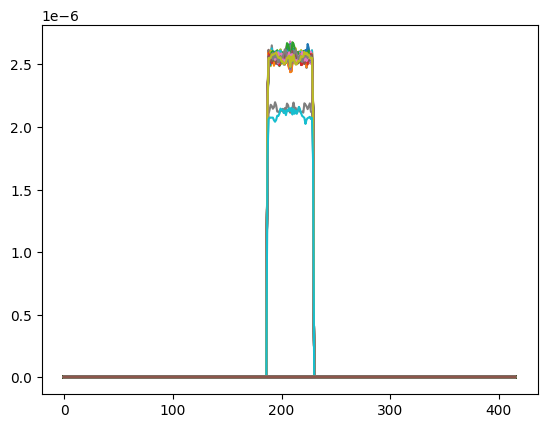

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

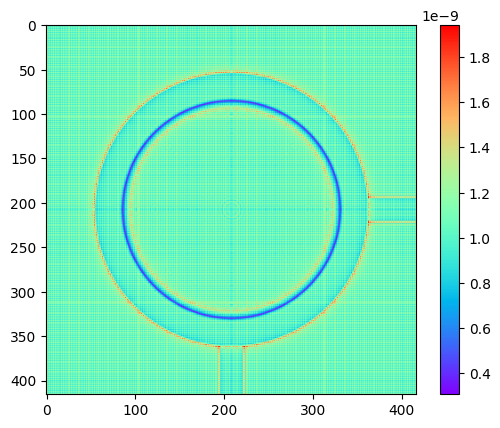

In [10]:
#100shots 1um material grid
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()